# Week 1: Data Ingestion & Exploratory Data Analysis (EDA)
### Project: SaaS/E-Commerce Cohort Retention & CLTV Analysis

This notebook covers the Week 1 tasks from the roadmap:
- Load the raw synthetic transaction dataset
- Inspect data quality (duplicates, missing values, refund status)
- Standardize the transaction dates
- Get an initial sense of user/transaction volume before cleaning


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("raw_transactions.csv", parse_dates=["transaction_date", "signup_date"])
df.shape

(17662, 7)

## 1. First look at the raw data

In [2]:
df.head()

,user_id,transaction_date,amount,status,acquisition_channel,region,signup_date
0,U00000,2025-04-18,40.85,completed,Referral,West,2025-04-13
1,NaN,2025-04-28,23.71,completed,Referral,West,2025-04-13
2,U00000,2025-04-13,34.76,completed,Referral,West,2025-04-13
3,U00000,2025-05-14,28.12,completed,Referral,West,2025-04-13
4,U00000,2025-05-17,35.83,completed,Referral,West,2025-04-13


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17662 entries, 0 to 17661
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              17574 non-null  str           
 1   transaction_date     17662 non-null  datetime64[us]
 2   amount               17662 non-null  float64       
 3   status               17662 non-null  str           
 4   acquisition_channel  17662 non-null  str           
 5   region               17662 non-null  str           
 6   signup_date          17662 non-null  datetime64[us]
dtypes: datetime64[us](2), float64(1), str(4)
memory usage: 966.0 KB


## 2. Data quality checks

Before any analysis, we need to understand how messy the raw export is.
Real-world exports from CRMs/analytics tools almost always have:
- Duplicate rows (double-logged events)
- Missing IDs (broken tracking pixels, failed joins)
- Refunded/failed transactions mixed in with real revenue


In [4]:
# Duplicate rows
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes} ({n_dupes/len(df)*100:.2f}% of data)")

Duplicate rows: 174 (0.99% of data)


In [5]:
# Missing user_id
n_missing = df['user_id'].isna().sum()
print(f"Rows with missing user_id: {n_missing} ({n_missing/len(df)*100:.2f}% of data)")

Rows with missing user_id: 88 (0.50% of data)


In [6]:
# Transaction status breakdown
df['status'].value_counts(normalize=True) * 100

status
completed    95.181746
refunded      4.818254
Name: proportion, dtype: float64

**Finding:** A small but meaningful share of rows are duplicates or missing a user_id,
and ~5% of transactions are refunds. All three need to be handled before building the
cohort matrix, otherwise churn and CLTV numbers will be inflated/skewed.


## 3. Timestamp sanity check

In [7]:
print("Earliest transaction:", df['transaction_date'].min())
print("Latest transaction:", df['transaction_date'].max())
print("Earliest signup:", df['signup_date'].min())
print("Latest signup:", df['signup_date'].max())

Earliest transaction: 2025-01-02 00:00:00
Latest transaction: 2026-01-26 00:00:00
Earliest signup: 2025-01-01 00:00:00
Latest signup: 2025-12-30 00:00:00


## 4. Transaction volume over time (before cleaning)

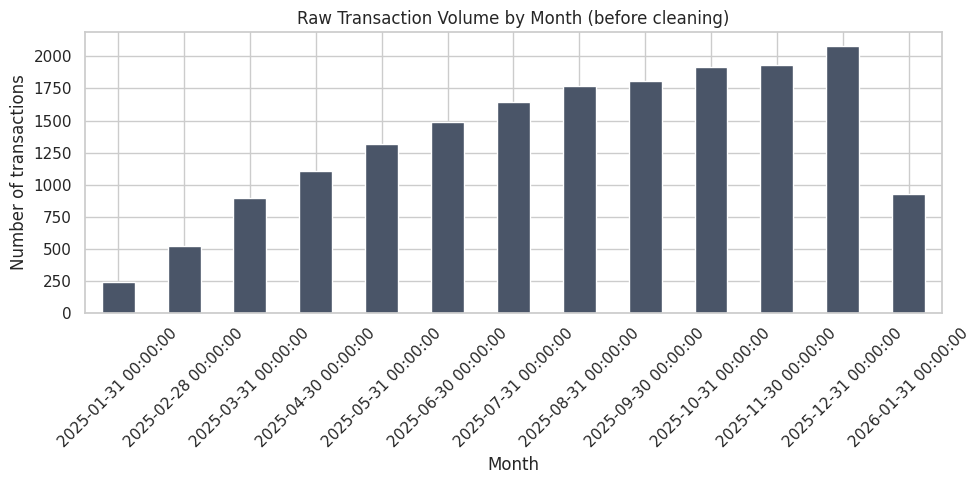

In [8]:
monthly_volume = df.set_index('transaction_date').resample('ME').size()

fig, ax = plt.subplots(figsize=(10, 5))
monthly_volume.plot(kind='bar', ax=ax, color='#4a5568')
ax.set_title('Raw Transaction Volume by Month (before cleaning)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Acquisition channel distribution

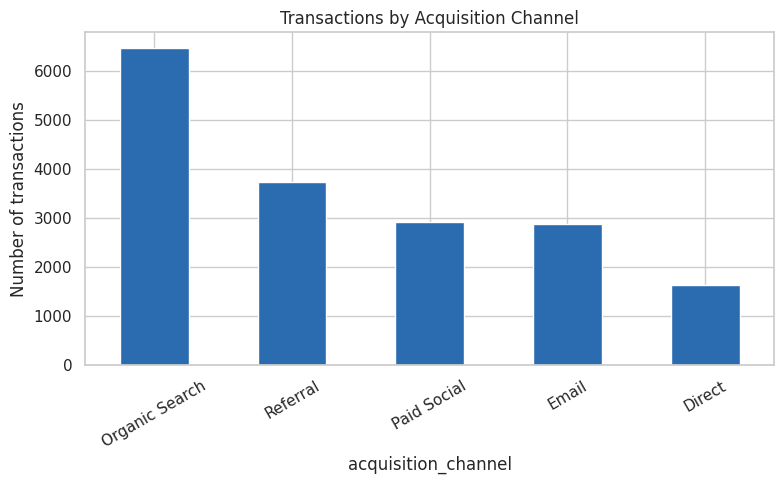

In [9]:
channel_counts = df['acquisition_channel'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
channel_counts.plot(kind='bar', ax=ax, color='#2b6cb0')
ax.set_title('Transactions by Acquisition Channel')
ax.set_ylabel('Number of transactions')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Summary of Week 1 findings

- Raw dataset has duplicate rows and missing `user_id` values that must be removed/dropped.
- ~5% of transactions are refunds and should be excluded from revenue-based metrics (CLTV).
- Transaction volume grows over the year as more cohorts are acquired, then naturally tapers
  for the newest cohorts (they haven't had time to accumulate transactions yet).
- Organic Search and Paid Social are the largest acquisition channels by transaction volume.

These findings directly informed the cleaning steps implemented in `cohort_analysis.py`
(Week 1 section): drop duplicates, drop missing `user_id`, filter to `status == "completed"`.
